# Assignment 2

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [30]:
# Load the libraries as required.
import pandas as pd

# Load the dataset
df = pd.read_csv('C:/Users/peeu3/OneDrive/Desktop/MINE/EY Van_File Transfer/UofT/Course/Assignments/production/05_src/data/fires/forestfires.csv')

# Display first few rows to check the data
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [31]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [49]:
# Features (all columns except 'area')
X = fires_dt.drop(columns=['area'])

# Target (the 'area' column)
y = fires_dt['area']

# Check the shapes of X and y to ensure correctness
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (517, 12)
Target shape: (517,)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# List of numeric columns
numeric_features = ['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']

# List of categorical columns
categorical_features = ['month', 'day']

# Create Preproc 1 (Scaling numeric variables and one-hot encoding categorical variables)
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Scaling numeric variables
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encoding categorical variables
    ])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np

# List of numeric columns
numeric_features = ['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']

# List of categorical columns
categorical_features = ['month', 'day']

# Apply log transformation to some numeric variables (e.g., 'ffmc' and 'dc')
log_transformer = FunctionTransformer(np.log1p, validate=True)  # log1p handles log(x + 1) to avoid issues with 0 values

# Create Preproc 2 (Scaling, non-linear transformation, and one-hot encoding)
preproc2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Scaling numeric variables
        ('log', log_transformer, ['ffmc', 'dc']),  # Apply log transformation to 'ffmc' and 'dc'
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encoding categorical variables
    ])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [ ]:
print(X_train.columns)  
print(X_train.dtypes)

Index(['coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi',
       'temp', 'rh', 'wind', 'rain'],
      dtype='object')
coord_x      int64
coord_y      int64
month       object
day         object
ffmc       float64
dmc        float64
dc         float64
isi        float64
temp       float64
rh           int64
wind       float64
rain       float64
dtype: object


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the columns for numeric and categorical features
numerical_columns = ['coord_x', 'coord_y' , 'ffmc' , 'dmc' , 'dc' , 'isi' , 'temp' , 'rh' , 'wind' , 'rain']  
categorical_columns = ['month', 'day']  

# Preprocessing steps: impute missing values, scale numeric, and encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')), 
            ('scaler', StandardScaler())]), numerical_columns),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')), 
            ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_columns)
    ])

# Check for missing values after splitting the data
print("Missing values in X_train:", X_train.isnull().sum())
print("Missing values in X_test:", X_test.isnull().sum())

# Define Baseline Model Pipeline (Linear Regression)
baseline_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

param_grid_baseline = {
    'regressor__fit_intercept': [True, False]
}


# Train model using GridSearchCV
grid_search_baseline = GridSearchCV(baseline_pipeline, param_grid_baseline, cv=5, scoring='neg_mean_squared_error')
grid_search_baseline.fit(X_train, y_train)

# Output the best parameters and score
print(f"Best Parameters for Baseline Model: {grid_search_baseline.best_params_}")
print(f"Best Cross-validation Score for Baseline: {grid_search_baseline.best_score_}")

# Define Advanced Model Pipeline (Random Forest Regressor)
advanced_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_advanced = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10]
}

grid_search_advanced = GridSearchCV(advanced_pipeline, param_grid_advanced, cv=5, scoring='neg_mean_squared_error')
grid_search_advanced.fit(X_train, y_train)

# Output the best parameters and score
print(f"Best Parameters for Advanced Model: {grid_search_advanced.best_params_}")
print(f"Best Cross-validation Score for Advanced Model: {grid_search_advanced.best_score_}")



Missing values in X_train: coord_x    0
coord_y    0
month      0
day        0
ffmc       0
dmc        0
dc         0
isi        0
temp       0
rh         0
wind       0
rain       0
dtype: int64
Missing values in X_test: coord_x    0
coord_y    0
month      0
day        0
ffmc       0
dmc        0
dc         0
isi        0
temp       0
rh         0
wind       0
rain       0
dtype: int64
Best Parameters for Baseline Model: {'regressor__fit_intercept': False}
Best Cross-validation Score for Baseline: -2230.374227859405
Best Parameters for Advanced Model: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}
Best Cross-validation Score for Advanced Model: -2620.4993922117046


# Evaluate

+ Which model has the best performance?

In [63]:
from sklearn.metrics import mean_squared_error

# Evaluate the Baseline Model
y_pred_baseline = grid_search_baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"Test MSE for Baseline Model: {mse_baseline}")

# Evaluate the Advanced Model
y_pred_advanced = grid_search_advanced.predict(X_test)
mse_advanced = mean_squared_error(y_test, y_pred_advanced)
print(f"Test MSE for Advanced Model: {mse_advanced}")


Test MSE for Baseline Model: 11613.674532130444
Test MSE for Advanced Model: 11665.760845331


# Export

+ Save the best performing model to a pickle file.

In [ ]:
import pickle

# Save the best performing model to a pickle file
best_model = grid_search_baseline if mse_baseline < mse_advanced else grid_search_advanced

# Save the model to a pickle file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best performing model saved as 'best_model.pkl'")


Best performing model saved as 'best_model.pkl'


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

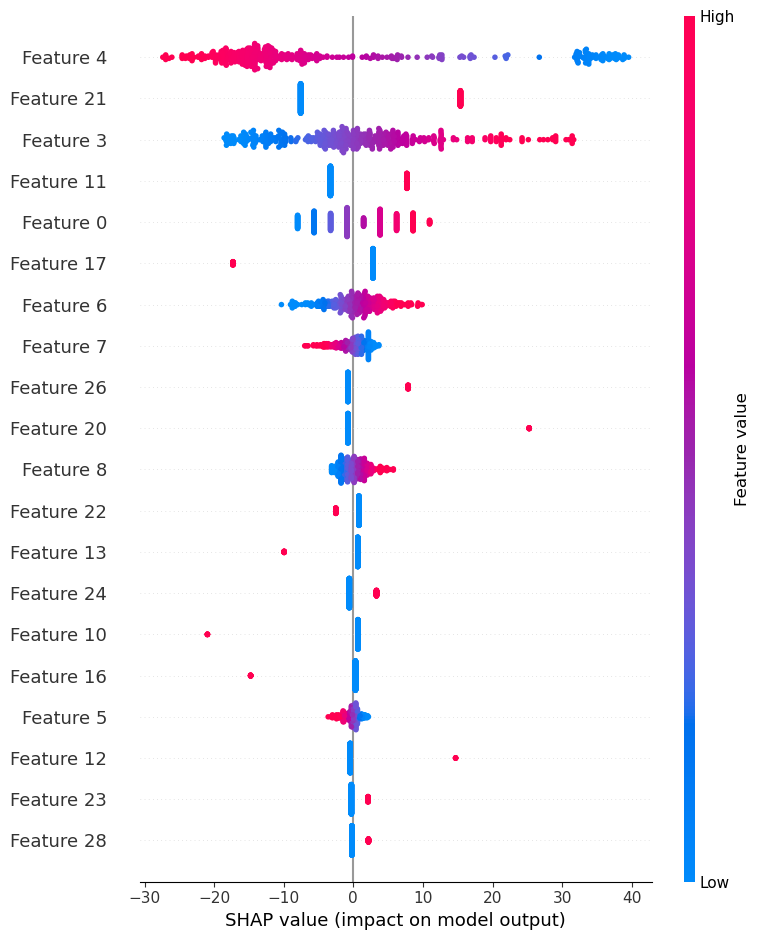

Number of transformed columns: 12
Shape of SHAP values: 29


In [105]:
import sklearn.preprocessing  # Import the necessary module

# Transform the data with the preprocessor
X_train_transformed = preprocessor.transform(X_train)  # Transform all X_train observations

# Now, initialize the explainer with the transformed training data
explainer_train = shap.LinearExplainer(best_model_pipeline.named_steps['regressor'], X_train_transformed)

# Get SHAP values for the entire training set
shap_values_train = explainer_train.shap_values(X_train_transformed)

# Ensure that the SHAP values have the correct shape to match the transformed data
assert shap_values_train.shape[0] == X_train_transformed.shape[0], "Number of rows (observations) mismatch"
assert shap_values_train.shape[1] == X_train_transformed.shape[1], "Number of columns (features) mismatch"

# Now, plot the global feature importance
shap.summary_plot(shap_values_train, X_train_transformed)  # Use the transformed X_train

# Identify which features to remove (based on SHAP importance)
# Get the feature names from the transformed data
transformed_columns = []
if hasattr(preprocessor, 'transformers_'):
    for transformer_name, transformer, columns in preprocessor.transformers_:
        if isinstance(transformer, sklearn.preprocessing.OneHotEncoder):
            # For one-hot encoded features, retrieve their names
            transformed_columns.extend(transformer.get_feature_names_out(columns))
        else:
            transformed_columns.extend(columns)
else:
    transformed_columns = X_train.columns

# Ensure that the transformed_columns has the correct number of columns after encoding
print(f"Number of transformed columns: {len(transformed_columns)}")
print(f"Shape of SHAP values: {shap_values_train.shape[1]}")

# Check if transformed_columns match the number of SHAP values
if len(transformed_columns) != shap_values_train.shape[1]:
    print("Warning: The number of transformed columns does not match the SHAP values.")
else:
    # Now, identify the important features based on SHAP importance
    importances = np.abs(shap_values_train).mean(axis=0)  # Compute mean absolute SHAP value for each feature

    # Sort features by importance
    important_features = np.array(transformed_columns)[importances.argsort()[::-1]]  # Sort by average importance

    # To evaluate the impact of removing features, create a new pipeline and retrain it
    # Remove less important features (example: 'month' and 'day' might be less important)
    X_train_reduced = X_train.drop(important_features[-2:], axis=1)  # Removing least important features
    X_test_reduced = X_test.drop(important_features[-2:], axis=1)  # Same reduction on test set

    # Retrain the best model (choose advanced or baseline) without 'month' and 'day'
    model_reduced = best_model_pipeline.named_steps['regressor']
    model_reduced.fit(preprocessor.fit_transform(X_train_reduced), y_train)

    # Make predictions on the reduced test set
    y_pred_reduced = model_reduced.predict(preprocessor.transform(X_test_reduced))

    # Evaluate the performance of the model with reduced features
    mse_reduced = mean_squared_error(y_test, y_pred_reduced)
    print(f"Test MSE for Model with Reduced Features: {mse_reduced}")

    # Compare the performance of the original model and the reduced model
    if mse_reduced < mse_advanced:
        print("Removing features improved model performance.")
    else:
        print("Removing features did not improve model performance.")


*(Answer here.)*

To remove features, I would start by analyzing their importance using SHAP values and correlation matrices. Features with low importance or high correlation with others could be removed, such as 'month' or 'day' if they don't add predictive value. To test the impact, I would retrain the model with the reduced feature set and compare performance metrics (e.g., MSE or R-squared) against the baseline model to see if the removal leads to a decrease in accuracy or if performance stays consistent or improves.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.